# Catboost vs ARIMA vs VAR

['ARIMA: RMSE = 0.375, MAPE = 8.76%', 'VAR: RMSE = 1.341, MAPE = 30.00%', 'CatBoost: RMSE = 0.298, MAPE = 6.82%']


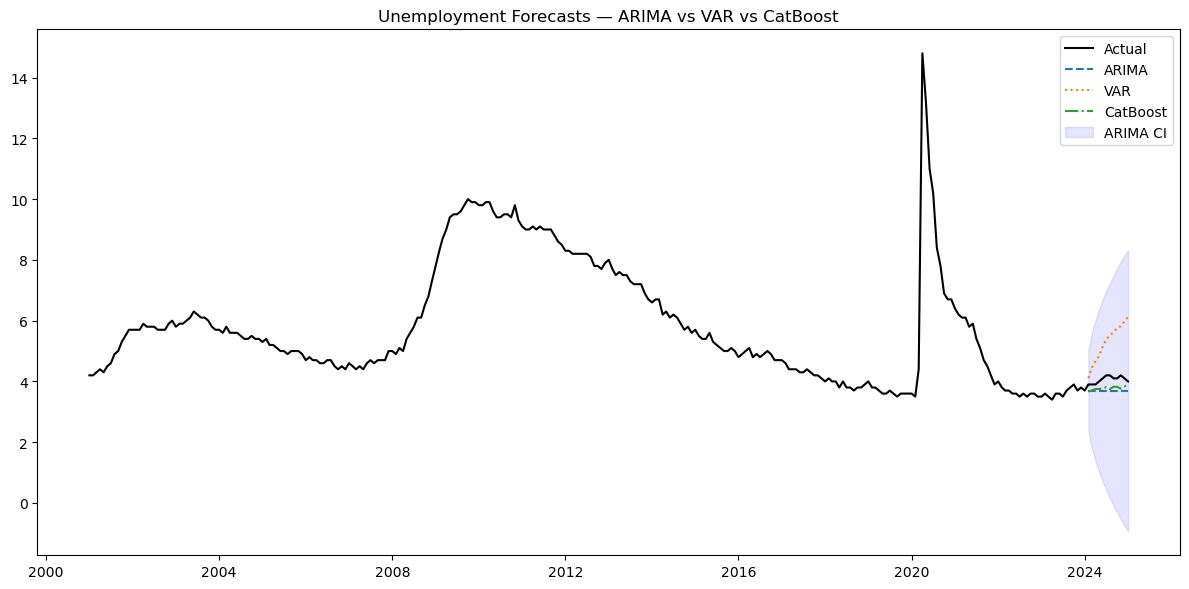

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fredapi import Fred
import pmdarima as pm
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from catboost import CatBoostRegressor

API_KEY = '4df2eca0f8e50e893ab9de7a4c006757'  fred = Fred(api_key=API_KEY)

unrate = fred.get_series('UNRATE', observation_start='2000-01-01').asfreq('MS').rename('UNRATE')
ic = fred.get_series('ICSA', observation_start='2000-01-01').resample('MS').mean().rename('ICSA')
cpi = fred.get_series('CPIAUCSL', observation_start='2000-01-01')
cpi_yoy = (cpi.pct_change(12) * 100).asfreq('MS').rename('CPI_YoY')
gdp = fred.get_series('GDPC1', observation_start='2000-01-01').resample('MS').ffill()
gdp_yoy = (gdp.pct_change(12) * 100).rename('GDP_YoY')
pce = fred.get_series('PCE', observation_start='2000-01-01').resample('MS').ffill()
pce_yoy = (pce.pct_change(12) * 100).rename('PCE_YoY')

df = pd.concat([unrate, ic, cpi_yoy, gdp_yoy, pce_yoy], axis=1).dropna()

train = df.iloc[:-12]
test = df.iloc[-12:]

#ARIMA FORECAST
arima = pm.auto_arima(train['UNRATE'], seasonal=True, m=12, trace=False)
arima_fore, confint = arima.predict(n_periods=12, return_conf_int=True)

#VAR FORECAST
var_model = VAR(train)
res_var = var_model.fit(maxlags=12, ic='aic')
var_fore = res_var.forecast(train.values[-res_var.k_ar:], steps=12)
var_fore = pd.DataFrame(var_fore, index=test.index, columns=train.columns)

#CATBOOST FORECAST
df_ml = df.copy()
for lag in range(1, 13):
    df_ml[f'UNRATE_lag{lag}'] = df_ml['UNRATE'].shift(lag)

df_ml = df_ml.dropna()
train_ml = df_ml.iloc[:-12]
test_ml = df_ml.iloc[-12:]

X_train = train_ml.drop('UNRATE', axis=1)
y_train = train_ml['UNRATE']
X_test = test_ml.drop('UNRATE', axis=1)
y_test = test_ml['UNRATE']

cat = CatBoostRegressor(verbose=0, iterations=500, depth=6, learning_rate=0.05, loss_function='RMSE')
cat.fit(X_train, y_train)
cat_fore = cat.predict(X_test)


df_eval = test.copy()
df_eval['ARIMA_UNRATE'] = arima_fore
df_eval['VAR_UNRATE'] = var_fore['UNRATE']
df_eval['CAT_UNRATE'] = cat_fore

def evaluate_forecast(true, pred, label):
    rmse = np.sqrt(mean_squared_error(true, pred))
    mape = mean_absolute_percentage_error(true, pred) * 100
    return f"{label}: RMSE = {rmse:.3f}, MAPE = {mape:.2f}%"

results = [
    evaluate_forecast(df_eval['UNRATE'], df_eval['ARIMA_UNRATE'], "ARIMA"),
    evaluate_forecast(df_eval['UNRATE'], df_eval['VAR_UNRATE'], "VAR"),
    evaluate_forecast(df_eval['UNRATE'], df_eval['CAT_UNRATE'], "CatBoost")
]


print(results)

plt.plot(df['UNRATE'], label='Actual', color='black')
plt.plot(df_eval.index, df_eval['ARIMA_UNRATE'], label='ARIMA', linestyle='--')
plt.plot(df_eval.index, df_eval['VAR_UNRATE'], label='VAR', linestyle=':')
plt.plot(df_eval.index, df_eval['CAT_UNRATE'], label='CatBoost', linestyle='-.')
plt.fill_between(df_eval.index, confint[:, 0], confint[:, 1], color='blue', alpha=0.1, label='ARIMA CI')
plt.title('Unemployment Forecasts — ARIMA vs VAR vs CatBoost')
plt.legend()
plt.tight_layout()
plt.show()